# 🩺 Diabetes Prediction using Naive Bayes
**Objective:** Predict whether a patient has diabetes based on diagnostic measurements (like BMI, blood glucose, and HbA1c levels) and demographic data. We will use the **Gaussian Naive Bayes** algorithm, which relies on Bayes' theorem and is highly efficient for medical classification tasks.

In [3]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(" Libraries Imported Successfully")

 Libraries Imported Successfully


---
### 📂 Step 1: Load Data & Smart Medical Cleaning
Medical datasets often contain data entry errors. We will filter out extreme, biologically improbable BMI outliers. We will also drop the `clinical_notes` column, as text processing (NLP) is outside the scope of this specific numerical model.

In [4]:
# Load Dataset (Ensure the filename matches your uploaded file)
df = pd.read_csv('diabetes_dataset_with_notes.csv')

# Drop the free-text column
if 'clinical_notes' in df.columns:
    df.drop('clinical_notes', axis=1, inplace=True)

# Drop redundant exact duplicates
df.drop_duplicates(inplace=True)

# Handle BMI Outliers (Interquartile Range Method)
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only valid BMI ranges
df = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]
df.reset_index(drop=True, inplace=True)

print(f"Dataset Shape after cleaning: {df.shape}")
display(df.head(3))

Dataset Shape after cleaning: (92900, 16)


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0


---
### 📊 Step 2: Exploratory Data Analysis (EDA)
Let's visualize how strong indicators like **Blood Glucose** and **HbA1c levels** relate to the Diabetes diagnosis.

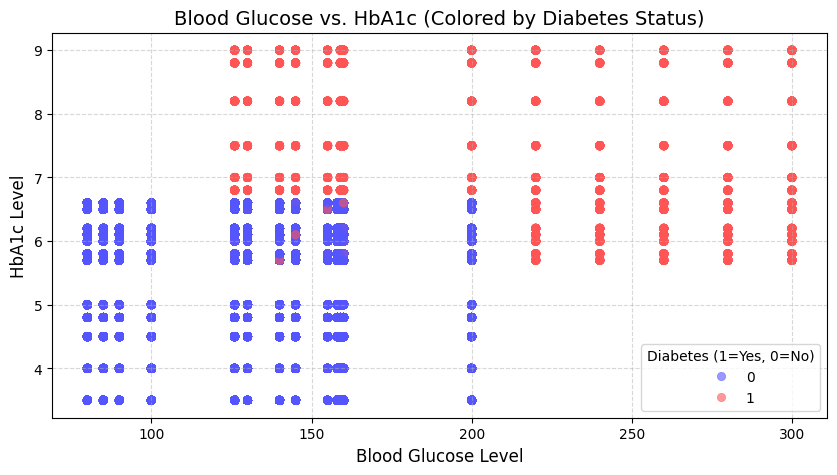

 Observation: Notice how the red dots (Diabetic patients) are tightly clustered at higher glucose and HbA1c levels. Naive Bayes will use these probability clusters to make predictions.


In [5]:
plt.figure(figsize=(10, 5))

# Scatter plot: Glucose vs HbA1c colored by Diabetes status
sns.scatterplot(x='blood_glucose_level', y='hbA1c_level', hue='diabetes', 
                data=df, palette='seismic', alpha=0.6, edgecolor=None)

plt.title('Blood Glucose vs. HbA1c (Colored by Diabetes Status)', fontsize=14)
plt.xlabel('Blood Glucose Level', fontsize=12)
plt.ylabel('HbA1c Level', fontsize=12)
plt.legend(title='Diabetes (1=Yes, 0=No)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(" Observation: Notice how the red dots (Diabetic patients) are tightly clustered at higher glucose and HbA1c levels. Naive Bayes will use these probability clusters to make predictions.")

---
### ✂️ Step 3: Feature Separation & Train-Test Split

In [6]:
# Separate Features (X) and Target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Dynamically identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

---
### 🏗️ Step 4: Build the Naive Bayes Classification Pipeline
We use `GaussianNB` which assumes that the continuous values associated with each class are distributed according to a normal (Gaussian) distribution.

In [7]:
# 1. Numerical Pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # Good practice to stabilize variance
])

# 2. Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 4. Full Pipeline with Gaussian Naive Bayes Classifier
nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

print(" Gaussian Naive Bayes Pipeline Built Successfully!")

 Gaussian Naive Bayes Pipeline Built Successfully!


---
### 🚀 Step 5: Train, Evaluate, and Visualize the Confusion Matrix

🏆 Naive Bayes Model Accuracy: 61.18%

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     17176
           1       0.15      0.92      0.26      1404

    accuracy                           0.61     18580
   macro avg       0.57      0.75      0.50     18580
weighted avg       0.93      0.61      0.70     18580



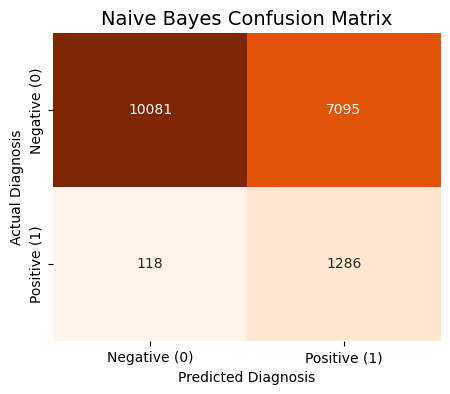

In [8]:
# Train the Pipeline
nb_pipeline.fit(X_train, y_train)

# Predict on Test Data
y_pred = nb_pipeline.predict(X_test)

# Evaluation Metrics
print(f"🏆 Naive Bayes Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📄 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Naive Bayes Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()